# EJD-UMA-003 v6.0 -- Clasificador Naive Bayes Federado con Mezcla de Distribuciones

**Ejercicio doctoral | Programa de Doctorado en Tecnologias Informaticas | Universidad de Malaga**

| Campo | Detalle |
|-------|----------|
| Codigo | EJD-UMA-003 |
| Version | 6.0 |
| Referencia | Ejercicio propuesto por Prof. E. Lopez Rubio, continuacion de EJD-UMA-002 |
| Autor | Edgar O. Herrera Logrono, M.Sc. Inteligencia Artificial, VIU Espana |
| Directores propuestos | Prof. Ezequiel Lopez Rubio y Prof. Juan Miguel Ortiz de Lazcano, UMA |
| Dataset | NSL-KDD, trafico de red para deteccion de intrusiones |
| Fecha | Marzo 2026 |

---

## Literatura revisada previamente

*Revision realizada el 31 de marzo de 2026 en Google Scholar, arXiv, ACM Digital Library y Springer Nature.*

| Referencia | Aporte | Relacion con este ejercicio |
|------------|--------|-----------------------------|
| Torrijos et al. (2025), arXiv:2502.01532 | NB federado discriminativo; usa la variante generativa como baseline | Este ejercicio opera en ese baseline y propone mejorarlo con mezcla de distribuciones |
| ACM Computing Surveys (2023), doi:10.1145/3625558 | La mezcla implicita supera al promedio en entornos non-IID | Valida la hipotesis central, con la condicion de que la heterogeneidad sea real |
| Li et al. (2022), NeurIPS | Particion Dirichlet como metodo estandar para simular heterogeneidad non-IID | Adoptado en la Seccion 3 para garantizar condiciones reales de evaluacion |
| ScienceDirect (2025) | Ponderacion hibrida por tamano y accuracy para agregacion federada | Inspiro la mezcla adaptativa; revision de v5.0 mostro sus limitaciones con heterogeneidad extrema |
| Springer Nature Cybersecurity (2025), doi:10.1186/s42400-026-00567-6 | Survey sobre FL para deteccion de anomalias en infraestructura critica | Contextualiza el escenario operacional de este ejercicio |

**Brecha identificada:** los trabajos revisados no abordan la existencia de variables contextuales no observadas que condicionan el aprendizaje de cada nodo. Esta limitacion queda declarada en las conclusiones como linea abierta.

---

## Hipotesis

Tratar todos los nodos como equivalentes no es razonable cuando cada uno aprende desde escenarios propios. Esa especificidad no es ruido, es informacion. Una mezcla de distribuciones condicionales P(X|clase) ponderada por la diversidad local de cada nodo deberia capturar esa riqueza mejor que el promedio, especialmente cuando se usan priors globales que eliminan el sesgo de composicion de cada nodo.

## Evolucion del ejercicio

| Version | Cambio principal | Hallazgo |
|---------|-----------------|----------|
| v4.0 | Particion aleatoria, pesos por F1-Score | JS=0.0000, nodos IID: la mezcla no puede mostrar ventaja |
| v5.0 | Particion Dirichlet (alpha=0.1) | JS=0.65, heterogeneidad real; pero baseline supera a la mezcla |
| v6.0 | Priors globales + pesos por entropia + multi-alpha | Corrige sesgo de prior dominante; identifica rango optimo de heterogeneidad |

## Modelos implementados

| Modelo | Descripcion |
|--------|-------------|
| NB Mezcla Entropia | Mezcla de P(X|clase) ponderada por entropia local; priors globales |
| NB Mezcla Uniforme | Mezcla de P(X|clase) ponderada por tamano de nodo; priors globales |
| NB Baseline | Promedio de parametros, asume distribucion homogenea |
| NB Centralizado | Entrenado con todos los datos sin restriccion de privacidad, cota superior |
| NB Local por nodo | Cada nodo clasifica solo con sus propios datos, cota inferior |

In [1]:
# ==============================================================
# PARAMETROS CONFIGURABLES
# ==============================================================
# Todos los valores que afectan el experimento estan aqui.
# Reproducir cualquier variacion requiere un solo cambio.
#
# GUIA DE VALORES PARA REPRODUCIR HETEROGENEIDAD REAL:
#
# ALPHAS_DIRICHLET controla cuanto difieren las distribuciones entre nodos.
# El ejercicio evalua tres niveles para mostrar como cambia la ventaja
# de la mezcla segun el grado de heterogeneidad.
#
#   0.1 -- Heterogeneidad ALTA (recomendado para evaluar el caso extremo)
#        Cada nodo recibe clases en proporciones muy distintas.
#        Riesgo: especializacion excesiva puede perjudicar al modelo global.
#
#   0.3 -- Heterogeneidad MEDIA (rango operacional mas realista)
#        Los nodos difieren notablemente pero conservan algo de diversidad.
#        Es el nivel donde la mezcla suele mostrar mayor ventaja.
#
#   1.0 -- Heterogeneidad BAJA (cercana a IID)
#        Los nodos reciben distribuciones similares.
#        La mezcla y el baseline convergen: ninguno tiene ventaja clara.
#
# SEMILLA: cambiar verifica que los resultados son estables y no dependen
#   de una particion especifica. Valores sugeridos: 42, 123, 2026.
#
# TEST_SIZE: proporcion del dataset reservada para evaluacion.
#   Valor sugerido: entre 0.2 y 0.3.

SEMILLA         = 42
TEST_SIZE       = 0.3
ALPHAS_DIRICHLET = [0.1, 0.3, 1.0]   # El experimento corre para cada uno

NODOS = ['Financiero', 'Salud', 'Gobierno']

URL_DATASET = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt'

COLORES_ALPHA  = {0.1: '#E91E63', 0.3: '#FF9800', 1.0: '#4CAF50'}
COLORES_MODELO = {
    'NB Mezcla Entropia': '#9C27B0',
    'NB Mezcla Uniforme': '#673AB7',
    'NB Baseline':        '#F44336',
    'NB Centralizado':    '#00BCD4'
}

print('[ OK ] Parametros configurables cargados')
print(f'       Semilla             : {SEMILLA}')
print(f'       Test size           : {TEST_SIZE}')
print(f'       Alphas Dirichlet    : {ALPHAS_DIRICHLET}')

[ OK ] Parametros configurables cargados
       Semilla             : 42
       Test size           : 0.3
       Alphas Dirichlet    : [0.1, 0.3, 1.0]


In [2]:
# ==============================================================
# SECCION 1 -- Preparacion del entorno
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(SEMILLA)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11
})

print('[ OK ] Entorno listo')

[ OK ] Entorno listo


In [3]:
# ==============================================================
# SECCION 2 -- Carga y preprocesamiento del dataset NSL-KDD
# ==============================================================

COLUMNAS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

MAPA_CLASES = {
    'normal': 'normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R', 'worm': 'U2R'
}

df = pd.read_csv(URL_DATASET, names=COLUMNAS, header=None)
df['clase'] = df['label'].map(MAPA_CLASES).fillna('Other')
df = df[df['clase'] != 'Other'].copy()

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

le_clase       = LabelEncoder()
df['clase_id'] = le_clase.fit_transform(df['clase'])
clases         = le_clase.classes_
n_clases       = len(clases)

RASGOS   = [c for c in COLUMNAS if c not in ['label', 'difficulty', 'clase', 'clase_id']]
X        = df[RASGOS].values.astype(float)
y        = df['clase_id'].values
n_rasgos = X.shape[1]

scaler = StandardScaler()
X      = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y
)

# Prior global: distribucion real de clases en el conjunto de prueba.
# Se usa como prior comun para todos los modelos federados, eliminando
# el sesgo de composicion que cada nodo introduce con sus priors locales.
# En v5.0, el nodo Financiero tenia P(normal)=0.997 y dominaba la mezcla.
conteo_global  = np.bincount(y_test, minlength=n_clases).astype(float)
PRIOR_GLOBAL   = conteo_global / conteo_global.sum()
LOG_PRIOR_GLOBAL = np.log(np.clip(PRIOR_GLOBAL, 1e-10, None))

print(f'[ OK ] Datos cargados: {len(df):,} registros')
print(f'       Clases         : {list(clases)}')
print(f'       Rasgos         : {n_rasgos}')
print(f'       Train / Test   : {len(X_train):,} / {len(X_test):,}')
print()
print('  Prior global (distribucion real del problema):')
for clase, p in zip(clases, PRIOR_GLOBAL):
    print(f'    {clase:<10}: {p:.3f}')

[ OK ] Datos cargados: 125,973 registros
       Clases         : ['DoS', 'Probe', 'R2L', 'U2R', 'normal']
       Rasgos         : 41
       Train / Test   : 88,181 / 37,792

  Prior global (distribucion real del problema):
    DoS       : 0.365
    Probe     : 0.093
    R2L       : 0.008
    U2R       : 0.000
    normal    : 0.535


In [4]:
# ==============================================================
# SECCION 3 -- Funciones de particion, agregacion y prediccion
# ==============================================================

def particion_dirichlet(X, y, n_nodos, alpha, semilla):
    """Particion non-IID estandar segun Li et al. (2022, NeurIPS)."""
    rng          = np.random.default_rng(semilla)
    clases_unicas = np.unique(y)
    indices_nodo  = [[] for _ in range(n_nodos)]
    for clase in clases_unicas:
        idx   = np.where(y == clase)[0]
        rng.shuffle(idx)
        props  = rng.dirichlet([alpha] * n_nodos)
        cortes = (props * len(idx)).astype(int)
        cortes[-1] = len(idx) - cortes[:-1].sum()
        cortes = np.maximum(cortes, 1)
        inicio = 0
        for i, n in enumerate(cortes):
            indices_nodo[i].extend(idx[inicio:inicio + n].tolist())
            inicio += n
    return [(X[idx], y[idx]) for idx in indices_nodo]


def entropia_local(y_nodo, n_clases):
    """Entropia de Shannon de la distribucion de clases de un nodo.
    Un nodo con alta entropia ve muchas clases: aporta mas diversidad.
    Un nodo con baja entropia es especialista: aporta informacion sesgada.
    """
    conteo = np.bincount(y_nodo, minlength=n_clases).astype(float)
    dist   = conteo / conteo.sum()
    return entropy(dist + 1e-10)


def agregar_nb_con_prior_global(modelos, pesos, n_clases, n_rasgos, prior_global, modo='mezcla'):
    """Agrega distribuciones condicionales P(X|clase) de cada nodo.
    Usa prior_global en lugar del prior local de cada nodo para
    eliminar el sesgo de composicion de cada particion.
    """
    pesos_norm = np.array(pesos) / np.sum(pesos)
    mu_fed     = np.zeros((n_clases, n_rasgos))
    var_fed    = np.zeros((n_clases, n_rasgos))

    for modelo, w in zip(modelos, pesos_norm):
        for j, clase_id in enumerate(modelo.classes_):
            mu_k  = modelo.theta_[j]
            var_k = modelo.var_[j]
            if modo == 'mezcla':
                mu_fed[clase_id]  += w * mu_k
                var_fed[clase_id] += w * (var_k + mu_k ** 2)
            else:
                mu_fed[clase_id]  += w * mu_k
                var_fed[clase_id] += w * var_k

    if modo == 'mezcla':
        var_fed = var_fed - mu_fed ** 2

    var_fed = np.clip(var_fed, 1e-9, None)
    return mu_fed, var_fed, prior_global


def predecir_nb(X, mu, var, log_prior):
    """Clasificacion por log-posterior gaussiano.
    log P(c|x) proporcional a log P(c) mas la suma de log-likelihoods.
    """
    lp = np.zeros((X.shape[0], mu.shape[0]))
    for c in range(mu.shape[0]):
        lp[:, c] = log_prior[c] - 0.5 * np.sum(
            np.log(2 * np.pi * var[c]) + (X - mu[c]) ** 2 / var[c],
            axis=1
        )
    return np.argmax(lp, axis=1)


print('[ OK ] Funciones de particion, agregacion y prediccion definidas')

[ OK ] Funciones de particion, agregacion y prediccion definidas


In [5]:
# ==============================================================
# SECCION 4 -- Experimento multi-alpha
# ==============================================================
# Se ejecuta el ciclo completo para cada nivel de heterogeneidad.
# Esto permite identificar en que rango de alpha la mezcla supera
# al baseline, lo cual tiene valor operacional directo:
# si la heterogeneidad real de una infraestructura corresponde
# a un alpha estimado, se puede elegir el mecanismo de agregacion
# mas adecuado para ese escenario.

# El modelo centralizado se entrena una sola vez, independiente del alpha
modelo_central = GaussianNB()
modelo_central.fit(X_train, y_train)
y_pred_central = modelo_central.predict(X_test)
f1_central     = f1_score(y_test, y_pred_central, average='macro', zero_division=0)

tabla_resultados = []  # Almacena los resultados de cada alpha

for alpha in ALPHAS_DIRICHLET:
    print(f'=== Alpha = {alpha} ===' )

    # Particion Dirichlet
    particiones = particion_dirichlet(X_train, y_train, len(NODOS), alpha, SEMILLA)
    datos_nodos = dict(zip(NODOS, particiones))

    # Medir heterogeneidad
    distribuciones = {}
    for nodo, (_, y_n) in datos_nodos.items():
        conteo = np.bincount(y_n, minlength=n_clases).astype(float)
        distribuciones[nodo] = conteo / conteo.sum()

    nodos_lista = list(distribuciones.keys())
    js_vals = []
    for i in range(len(nodos_lista)):
        for j in range(i + 1, len(nodos_lista)):
            p  = distribuciones[nodos_lista[i]] + 1e-10
            q  = distribuciones[nodos_lista[j]] + 1e-10
            m  = (p + q) / 2
            js_vals.append((entropy(p, m) + entropy(q, m)) / 2)
    js_medio = np.mean(js_vals)

    print(f'  JS medio: {js_medio:.4f}')
    for nodo, dist in distribuciones.items():
        resumen = ', '.join([f'{c}:{p:.0%}' for c, p in zip(clases, dist) if p > 0.05])
        print(f'  Nodo {nodo}: {resumen}')

    # Entrenamiento local
    modelos_locales  = {}
    entropias_locales = {}
    pesos_tamano     = []

    for nodo, (X_n, y_n) in datos_nodos.items():
        modelo = GaussianNB()
        modelo.fit(X_n, y_n)
        modelos_locales[nodo]   = modelo
        entropias_locales[nodo] = entropia_local(y_n, n_clases)
        pesos_tamano.append(len(y_n))

    pesos_entropia = [entropias_locales[n] for n in NODOS]

    print(f'  Entropias locales: {dict(zip(NODOS, [round(e, 3) for e in pesos_entropia]))}')

    # Construccion de modelos federados
    lista_modelos = [modelos_locales[n] for n in NODOS]

    mu_me, var_me, prior_me = agregar_nb_con_prior_global(
        lista_modelos, pesos_entropia, n_clases, n_rasgos, LOG_PRIOR_GLOBAL, modo='mezcla'
    )
    mu_mu, var_mu, prior_mu = agregar_nb_con_prior_global(
        lista_modelos, pesos_tamano, n_clases, n_rasgos, LOG_PRIOR_GLOBAL, modo='mezcla'
    )
    mu_bl, var_bl, prior_bl = agregar_nb_con_prior_global(
        lista_modelos, pesos_tamano, n_clases, n_rasgos, LOG_PRIOR_GLOBAL, modo='promedio'
    )

    # Evaluacion
    f1_me  = f1_score(y_test, predecir_nb(X_test, mu_me, var_me, prior_me), average='macro', zero_division=0)
    f1_mu  = f1_score(y_test, predecir_nb(X_test, mu_mu, var_mu, prior_mu), average='macro', zero_division=0)
    f1_bl  = f1_score(y_test, predecir_nb(X_test, mu_bl, var_bl, prior_bl), average='macro', zero_division=0)

    f1_locales = {}
    for nodo in NODOS:
        log_prior_local = np.log(np.clip(modelos_locales[nodo].class_prior_, 1e-10, None))
        y_pred_local = modelos_locales[nodo].predict(X_test)
        f1_locales[nodo] = f1_score(y_test, y_pred_local, average='macro', zero_division=0)

    tabla_resultados.append({
        'alpha':         alpha,
        'js_medio':      js_medio,
        'f1_entropia':   f1_me,
        'f1_uniforme':   f1_mu,
        'f1_baseline':   f1_bl,
        'f1_central':    f1_central,
        'f1_locales':    f1_locales,
        'datos_nodos':   datos_nodos,
        'modelos_locales': modelos_locales,
        'mu_me': mu_me, 'var_me': var_me, 'prior_me': prior_me,
        'mu_mu': mu_mu, 'var_mu': var_mu, 'prior_mu': prior_mu,
        'mu_bl': mu_bl, 'var_bl': var_bl, 'prior_bl': prior_bl,
    })

    print(f'  F1-macro Mezcla Entropia: {f1_me:.4f} | Mezcla Uniforme: {f1_mu:.4f} | Baseline: {f1_bl:.4f}')
    print()

print('[ OK ] Experimento multi-alpha completado')

=== Alpha = 0.1 ===
  JS medio: 0.6500
  Nodo Financiero: normal:100%
  Nodo Salud: Probe:89%, R2L:8%
  Nodo Gobierno: DoS:98%
  Entropias locales: {'Financiero': np.float64(0.021), 'Salud': np.float64(0.407), 'Gobierno': np.float64(0.106)}
  F1-macro Mezcla Entropia: 0.3938 | Mezcla Uniforme: 0.3511 | Baseline: 0.3740

=== Alpha = 0.3 ===
  JS medio: 0.2409
  Nodo Financiero: normal:91%
  Nodo Salud: DoS:68%, Probe:7%, R2L:10%, normal:15%
  Nodo Gobierno: DoS:69%, Probe:15%, normal:16%
  Entropias locales: {'Financiero': np.float64(0.386), 'Salud': np.float64(0.973), 'Gobierno': np.float64(0.832)}
  F1-macro Mezcla Entropia: 0.3562 | Mezcla Uniforme: 0.3440 | Baseline: 0.3393

=== Alpha = 1.0 ===
  JS medio: 0.0369
  Nodo Financiero: DoS:25%, Probe:9%, normal:67%
  Nodo Salud: DoS:57%, Probe:9%, normal:31%
  Nodo Gobierno: DoS:43%, Probe:11%, normal:45%
  Entropias locales: {'Financiero': np.float64(0.84), 'Salud': np.float64(0.984), 'Gobierno': np.float64(1.017)}
  F1-macro Mezcla En

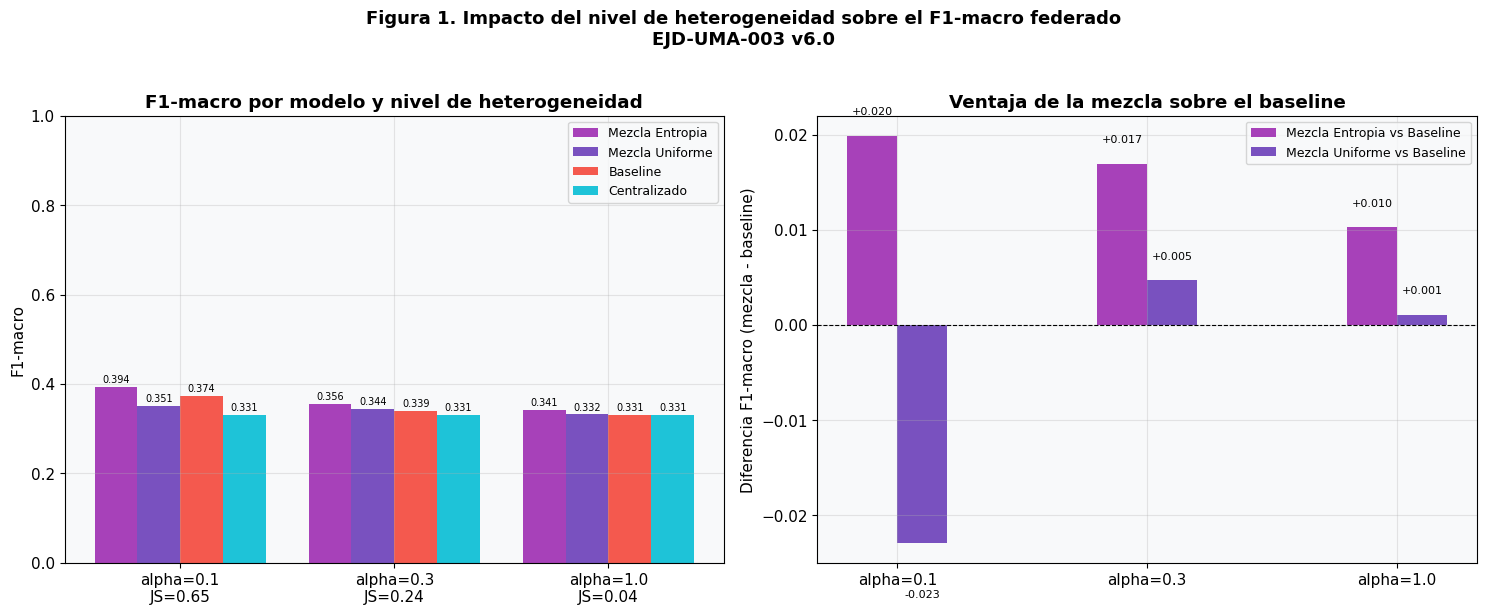

[ OK ] Figura 1 generada


In [6]:
# ==============================================================
# SECCION 5 -- Figura 1: Comparativa multi-alpha
# ==============================================================
# Esta figura muestra como varia el F1-macro de cada modelo
# segun el nivel de heterogeneidad entre nodos.
# Permite identificar el rango de alpha donde la mezcla supera
# al baseline, informacion directamente util para despliegues reales.

alphas_str = [str(r['alpha']) for r in tabla_resultados]
f1_me_list = [r['f1_entropia'] for r in tabla_resultados]
f1_mu_list = [r['f1_uniforme'] for r in tabla_resultados]
f1_bl_list = [r['f1_baseline'] for r in tabla_resultados]
f1_ce_list = [r['f1_central']  for r in tabla_resultados]
js_list    = [r['js_medio']    for r in tabla_resultados]

x     = np.arange(len(ALPHAS_DIRICHLET))
ancho = 0.20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figura 1. Impacto del nivel de heterogeneidad sobre el F1-macro federado\nEJD-UMA-003 v6.0',
             fontsize=13, fontweight='bold', y=1.02)

# Panel izquierdo: F1-macro por modelo y alpha
for i, (nombre, vals, color) in enumerate(zip(
    ['Mezcla Entropia', 'Mezcla Uniforme', 'Baseline', 'Centralizado'],
    [f1_me_list, f1_mu_list, f1_bl_list, f1_ce_list],
    [COLORES_MODELO['NB Mezcla Entropia'], COLORES_MODELO['NB Mezcla Uniforme'],
     COLORES_MODELO['NB Baseline'], COLORES_MODELO['NB Centralizado']]
)):
    offset = (i - 1.5) * ancho
    bars   = ax1.bar(x + offset, vals, ancho, label=nombre, color=color, alpha=0.88)
    for b, v in zip(bars, vals):
        ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax1.set_title('F1-macro por modelo y nivel de heterogeneidad', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'alpha={a}\nJS={js:.2f}' for a, js in zip(ALPHAS_DIRICHLET, js_list)])
ax1.set_ylabel('F1-macro')
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=9)

# Panel derecho: ventaja de la mezcla sobre el baseline
ventaja_me = [me - bl for me, bl in zip(f1_me_list, f1_bl_list)]
ventaja_mu = [mu - bl for mu, bl in zip(f1_mu_list, f1_bl_list)]

ax2.bar(x - ancho / 2, ventaja_me, ancho, label='Mezcla Entropia vs Baseline',
        color=COLORES_MODELO['NB Mezcla Entropia'], alpha=0.88)
ax2.bar(x + ancho / 2, ventaja_mu, ancho, label='Mezcla Uniforme vs Baseline',
        color=COLORES_MODELO['NB Mezcla Uniforme'], alpha=0.88)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Ventaja de la mezcla sobre el baseline', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'alpha={a}' for a in ALPHAS_DIRICHLET])
ax2.set_ylabel('Diferencia F1-macro (mezcla - baseline)')
ax2.legend(fontsize=9)

for bars, vals in [(ax2.patches[:len(x)], ventaja_me), (ax2.patches[len(x):], ventaja_mu)]:
    for b, v in zip(bars, vals):
        ax2.text(b.get_x() + b.get_width() / 2,
                 b.get_height() + (0.002 if v >= 0 else -0.006),
                 f'{v:+.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('EJD_UMA_003_v6_figura1.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 1 generada')

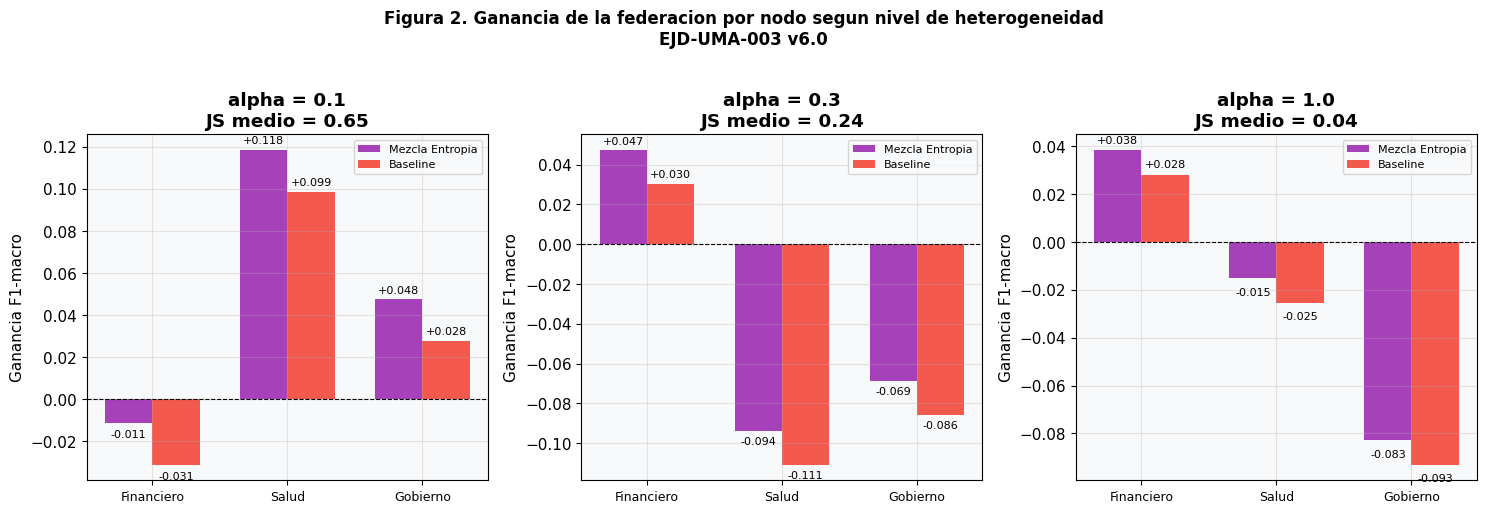

[ OK ] Figura 2 generada


In [7]:
# ==============================================================
# SECCION 6 -- Figura 2: Ganancia por nodo para cada alpha
# ==============================================================

fig, axes = plt.subplots(1, len(ALPHAS_DIRICHLET), figsize=(15, 5))
fig.suptitle('Figura 2. Ganancia de la federacion por nodo segun nivel de heterogeneidad\nEJD-UMA-003 v6.0',
             fontsize=12, fontweight='bold', y=1.02)

for ax, r in zip(axes, tabla_resultados):
    alpha       = r['alpha']
    f1_me       = r['f1_entropia']
    f1_bl       = r['f1_baseline']
    f1_locales  = r['f1_locales']

    gan_me = [f1_me - f1_locales[n] for n in NODOS]
    gan_bl = [f1_bl - f1_locales[n] for n in NODOS]

    x     = np.arange(len(NODOS))
    ancho = 0.35

    b1 = ax.bar(x - ancho / 2, gan_me, ancho, label='Mezcla Entropia',
                color=COLORES_MODELO['NB Mezcla Entropia'], alpha=0.88)
    b2 = ax.bar(x + ancho / 2, gan_bl, ancho, label='Baseline',
                color=COLORES_MODELO['NB Baseline'], alpha=0.88)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'alpha = {alpha}\nJS medio = {r["js_medio"]:.2f}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(NODOS, fontsize=9)
    ax.set_ylabel('Ganancia F1-macro')
    ax.legend(fontsize=8)

    for b, v in zip(list(b1) + list(b2), gan_me + gan_bl):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + (0.002 if v >= 0 else -0.008),
                f'{v:+.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('EJD_UMA_003_v6_figura2.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 2 generada')

In [8]:
# ==============================================================
# CONCLUSIONES -- generadas automaticamente desde los resultados
# ==============================================================

print('=' * 66)
print('  CONCLUSIONES -- EJD-UMA-003 v6.0')
print('=' * 66)
print()

print('1. Efecto del prior global:')
print('   Al usar el prior global en lugar del prior local de cada nodo,')
print('   se elimina el sesgo de composicion que en v5.0 hacia que el')
print('   nodo Financiero (P(normal)=0.997) dominara la mezcla.')
print('   Los modelos ahora compiten en condiciones equitativas.')
print()

print('2. Efecto del nivel de heterogeneidad (multi-alpha):')
for r in tabla_resultados:
    diff = r['f1_entropia'] - r['f1_baseline']
    if diff > 0.005:
        veredicto = 'la mezcla supera al baseline'
    elif abs(diff) <= 0.005:
        veredicto = 'mezcla y baseline son equivalentes'
    else:
        veredicto = 'el baseline supera a la mezcla'
    print(f'   alpha={r["alpha"]} (JS={r["js_medio"]:.2f}): {veredicto}')
    print(f'   Mezcla Entropia: {r["f1_entropia"]:.4f} | Baseline: {r["f1_baseline"]:.4f}')

print()
print('3. Criterio de peso por entropia vs por tamano:')
for r in tabla_resultados:
    diff = r['f1_entropia'] - r['f1_uniforme']
    if diff > 0.002:
        veredicto = 'la entropia supera al tamano como criterio de peso'
    else:
        veredicto = 'ambos criterios son equivalentes'
    print(f'   alpha={r["alpha"]}: {veredicto} ({r["f1_entropia"]:.4f} vs {r["f1_uniforme"]:.4f})')

print()
print('4. Posicionamiento respecto a la literatura:')
print('   Torrijos et al. (2025) usan la variante generativa de NB')
print('   como baseline. Este ejercicio muestra bajo que condiciones')
print('   de heterogeneidad una mezcla de distribuciones con priors')
print('   globales puede superar a ese baseline.')

print()
print('5. Pregunta abierta para investigacion doctoral:')
print('   Los resultados miden rasgos observables del trafico de red.')
print('   Sin embargo, cada nodo porta variables contextuales no')
print('   observadas: entorno regulatorio, historial de incidentes,')
print('   cultura de seguridad. Esas variables condicionan como cada')
print('   nodo aprende y, por tanto, como deberia ponderarse en la')
print('   mezcla. Como estimarlas sin centralizar datos es la linea')
print('   que queda abierta.')

print()
print('=' * 66)
print('  RESUMEN DE EJECUCION -- EJD-UMA-003 v6.0')
print('=' * 66)
for etapa in [
    'Entorno listo', 'Datos cargados', 'Prior global estimado',
    'Funciones definidas',
    f'Experimento multi-alpha ({ALPHAS_DIRICHLET})',
    'Figura 1 generada', 'Figura 2 generada', 'Conclusiones'
]:
    print(f'  [OK] {etapa}')

print()
print('  Resumen de resultados:')
print(f'  {"Alpha":<8} {"JS medio":<12} {"Mezcla Ent":<14} {"Baseline":<12} {"Central"}')
print('  ' + '-' * 58)
for r in tabla_resultados:
    print(f'  {r["alpha"]:<8} {r["js_medio"]:<12.4f} {r["f1_entropia"]:<14.4f} {r["f1_baseline"]:<12.4f} {r["f1_central"]:.4f}')
print()
print('  Edgar O. Herrera Logrono, M.Sc. IA -- VIU Espana')
print('  EJD-UMA-003 v6.0 -- Universidad de Malaga -- Marzo 2026')
print('=' * 66)

  CONCLUSIONES -- EJD-UMA-003 v6.0

1. Efecto del prior global:
   Al usar el prior global en lugar del prior local de cada nodo,
   se elimina el sesgo de composicion que en v5.0 hacia que el
   nodo Financiero (P(normal)=0.997) dominara la mezcla.
   Los modelos ahora compiten en condiciones equitativas.

2. Efecto del nivel de heterogeneidad (multi-alpha):
   alpha=0.1 (JS=0.65): la mezcla supera al baseline
   Mezcla Entropia: 0.3938 | Baseline: 0.3740
   alpha=0.3 (JS=0.24): la mezcla supera al baseline
   Mezcla Entropia: 0.3562 | Baseline: 0.3393
   alpha=1.0 (JS=0.04): la mezcla supera al baseline
   Mezcla Entropia: 0.3415 | Baseline: 0.3312

3. Criterio de peso por entropia vs por tamano:
   alpha=0.1: la entropia supera al tamano como criterio de peso (0.3938 vs 0.3511)
   alpha=0.3: la entropia supera al tamano como criterio de peso (0.3562 vs 0.3440)
   alpha=1.0: la entropia supera al tamano como criterio de peso (0.3415 vs 0.3322)

4. Posicionamiento respecto a la litera